# Member 1: Adult Income Fairness Audit

This notebook supports the H9DAI group project by building the Member 1 analysis for the UCI Adult Income dataset. The analysis is framed as a benchmark fairness audit of a canonical dataset rather than a claim about contemporary labour-market conditions.

## Reproducibility Note

The notebook is designed to run top-to-bottom on a fresh kernel. In this initial setup pass, only the dataset acquisition cell and the imports/configuration cell are included. Later CRISP-DM phases will be added after setup confirmation.

### Setup Cell 1

**What this cell achieves:** Downloads the Adult dataset files into `../data/adult/` if they are not already present and verifies that the required files exist.

**Expected output:** Confirmation messages showing whether files were downloaded or already available, followed by a success message.

In [ ]:
# Cell 1: Download Adult Income dataset
from pathlib import Path
import urllib.request

data_dir = Path("../data/adult")
data_dir.mkdir(parents=True, exist_ok=True)

base_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"
required_files = ["adult.data", "adult.test", "adult.names"]

for filename in required_files:
    destination = data_dir / filename
    if destination.exists():
        print(f"{filename} already exists at {destination}.")
    else:
        urllib.request.urlretrieve(base_url + filename, destination)
        print(f"Downloaded {filename} to {destination}.")

for filename in required_files:
    assert (data_dir / filename).exists(), f"Missing required dataset file: {filename}"

print("Adult Income dataset setup complete.")


adult.data already exists at ../data/adult/adult.data.
adult.test already exists at ../data/adult/adult.test.
adult.names already exists at ../data/adult/adult.names.
Adult Income dataset setup complete.


### Setup Cell 2

**What this cell achieves:** Imports the core libraries for the notebook, suppresses warnings, sets the plotting style, and defines the shared random seed constant.

**Expected output:** A short confirmation message showing that imports and configuration completed successfully.

In [ ]:
# Cell 2: Import libraries and configure the notebook environment
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

assert RANDOM_STATE == 42, "RANDOM_STATE must remain fixed at 42."
print(f"Imports and configuration loaded successfully. RANDOM_STATE={RANDOM_STATE}")


Imports and configuration loaded successfully. RANDOM_STATE=42


## 1. Business Understanding

### Research Focus

**Member 1 sub-question:** To what degree do machine learning classifiers reflect racial and gender bias when classifying whether an individual in the Adult Income dataset earns more than $50K per year?

This notebook addresses the employment domain of the group project by examining fairness-accuracy trade-offs in a widely used benchmark dataset. The practical motivation is that income classification tasks can act as a simplified proxy for downstream high-impact employment and socioeconomic decision systems, which are increasingly scrutinised under risk-based governance frameworks such as the EU AI Act.

### Analytical Objective

The objective is not to claim discovery of a new form of discrimination. Instead, the goal is to perform a transparent benchmark fairness audit using four standard classifiers and to compare whether model choice changes the balance between predictive performance and demographic disparities.

### Target and Protected Attributes

- **Target variable:** `income` classified as `>50K` versus `<=50K`
- **Primary protected attributes for fairness evaluation:** `race` and `sex`
- **Contextual protected attribute:** `age`

Race and sex are treated as the main fairness dimensions in this member notebook because they map directly to the required subgroup evaluations and allow a consistent comparison with standard fairness literature. Age is acknowledged as a protected characteristic in employment contexts, but it is not used as a primary fairness split in this notebook because the assessment brief requires race- and sex-focused outputs, and introducing age as a third full fairness axis would expand the analysis beyond the defined Member 1 deliverables.

### Academic Framing

The notebook is informed by three core fairness references:

- **Barocas and Selbst (2016)** on how data-driven systems can reproduce disparate impact even without explicit discriminatory intent
- **Hardt, Price, and Srebro (2016)** on equality of opportunity and error-rate based fairness criteria such as equalized odds
- **Mehrabi et al. (2021)** on the broader taxonomy of bias, fairness definitions, and trade-offs in machine learning systems

These references matter because the chosen fairness metrics do not measure the same concept. Demographic parity focuses on parity in positive classification rates, whereas equalized odds focuses on parity in error behaviour conditional on the true class. A model may improve on one fairness criterion while worsening another, so fairness results must be interpreted as trade-offs rather than absolute judgments.

### Benchmark Scope and Limitations

The Adult dataset is a canonical benchmark in fairness research, but it has known limitations. It is derived from the 1994 US Census, reflects historical and US-centric social categories, and uses an income threshold that does not represent current labour-market conditions. For that reason, this notebook treats the dataset as a controlled benchmark for comparative model behaviour, not as a contemporary representation of employment inequality and not as a basis for causal claims or legal compliance conclusions.

### Success Criteria for This Notebook

The Member 1 notebook will be considered successful if it:

1. builds a reproducible Adult Income analysis pipeline under CRISP-DM,
2. compares four required classifiers using standard performance metrics,
3. measures fairness for race and sex using the required metrics,
4. exports the exact figures and CSV outputs needed by the group synthesis notebook, and
5. communicates findings with appropriate methodological caution and benchmark-specific limitations.

> **Phase 1 insight for the report:** This notebook is positioned as a benchmark fairness audit of a canonical dataset. The core value is not proving that historical data can contain bias, but showing how different classifiers operationalise that history differently and what performance-fairness trade-offs appear when race and sex are examined explicitly.

## 2. Data Understanding

This phase establishes the empirical baseline for the Adult dataset before any preprocessing or modelling decisions are made. The focus is on raw data structure, missing-value markers, class balance, and demographic distributions so that later fairness results are interpreted in context rather than in isolation.

### Data Understanding Cell 1

**What this cell achieves:** Loads the raw Adult training and test files, aligns their schema, standardises the income labels, combines them into a single audit dataframe, and verifies the expected dataset size.

**Expected output:** Printed shapes for the train, test, and combined datasets, plus a short preview of the combined dataframe.

In [ ]:
# Cell 3: Load and combine the raw Adult Income data
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
    "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
    "hours_per_week", "native_country", "income"
]

adult_train_raw = pd.read_csv(
    data_dir / "adult.data",
    names=column_names,
    sep=r",\s*",
    engine="python",
    na_values="?",
    skipinitialspace=True
)

adult_test_raw = pd.read_csv(
    data_dir / "adult.test",
    names=column_names,
    sep=r",\s*",
    engine="python",
    na_values="?",
    skiprows=1,
    skipinitialspace=True
)

adult_train_raw["source_split"] = "train_file"
adult_test_raw["source_split"] = "test_file"
adult_test_raw["income"] = adult_test_raw["income"].str.replace(".", "", regex=False)

adult_df_raw = pd.concat([adult_train_raw, adult_test_raw], ignore_index=True)

assert adult_df_raw.shape[0] == 48842, f"Expected 48842 rows, found {adult_df_raw.shape[0]}"
assert set(adult_df_raw["income"].dropna().unique()) == {"<=50K", ">50K"}, "Unexpected target labels found."

print(f"Training file shape: {adult_train_raw.shape}")
print(f"Test file shape: {adult_test_raw.shape}")
print(f"Combined dataset shape: {adult_df_raw.shape}")
display(adult_df_raw.head())


Training file shape: (32561, 16)
Test file shape: (16281, 16)
Combined dataset shape: (48842, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train_file
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train_file
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train_file
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train_file
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train_file


> **Key insight for the report:** This loading step confirms the benchmark unit of analysis and prevents avoidable downstream errors such as mismatched schemas or inconsistent target labels between the original train and test files.

### Data Understanding Cell 2

**What this cell achieves:** Audits the raw dataset structure by checking data types, missing-value markers, duplicate rows, target distribution, and subgroup counts for the main protected attributes.

**Expected output:** Printed summaries for missing values, duplicates, class balance, and demographic counts that can be cited in the notebook narrative.

In [ ]:
# Cell 4: Audit schema, missing values, duplicates, and class balance
missing_summary = adult_df_raw.isna().sum().sort_values(ascending=False)
duplicate_count = adult_df_raw.drop(columns=["source_split"]).duplicated().sum()
income_counts = adult_df_raw["income"].value_counts().rename("count")
income_proportions = adult_df_raw["income"].value_counts(normalize=True).mul(100).round(2).rename("percentage")
race_counts = adult_df_raw["race"].value_counts().rename("count")
sex_counts = adult_df_raw["sex"].value_counts().rename("count")

assert income_counts.sum() == len(adult_df_raw), "Income class counts do not match dataset size."

print("Data types:")
print(adult_df_raw.dtypes)
print("\nMissing values by column:")
print(missing_summary[missing_summary > 0])
print(f"\nDuplicate rows (excluding source_split): {duplicate_count}")
print("\nIncome class counts:")
print(pd.concat([income_counts, income_proportions], axis=1))
print("\nRace distribution:")
print(race_counts)
print("\nSex distribution:")
print(sex_counts)


Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
source_split        str
dtype: object

Missing values by column:
occupation        2809
workclass         2799
native_country     857
dtype: int64

Duplicate rows (excluding source_split): 52

Income class counts:
        count  percentage
income                   
<=50K   37155       76.07
>50K    11687       23.93

Race distribution:
race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

Sex distribution:
sex
Male      32650
Female    16192
Name: count, dtype: int64


> **Key insight for the report:** This audit establishes whether the dataset is class-imbalanced and whether missingness or subgroup under-representation could distort later fairness comparisons. These checks matter because fairness metrics can look unstable or misleading when evaluated on sparse or uneven subgroups.

### Data Understanding Cell 3

**What this cell achieves:** Visualises the demographic composition of the benchmark dataset across race, sex, and age, then saves the figure required for the paper.

**Expected output:** A three-panel figure showing demographic distributions, a saved image file at `../paper/figures/m1_demographic_distributions.png`, and a confirmation message.

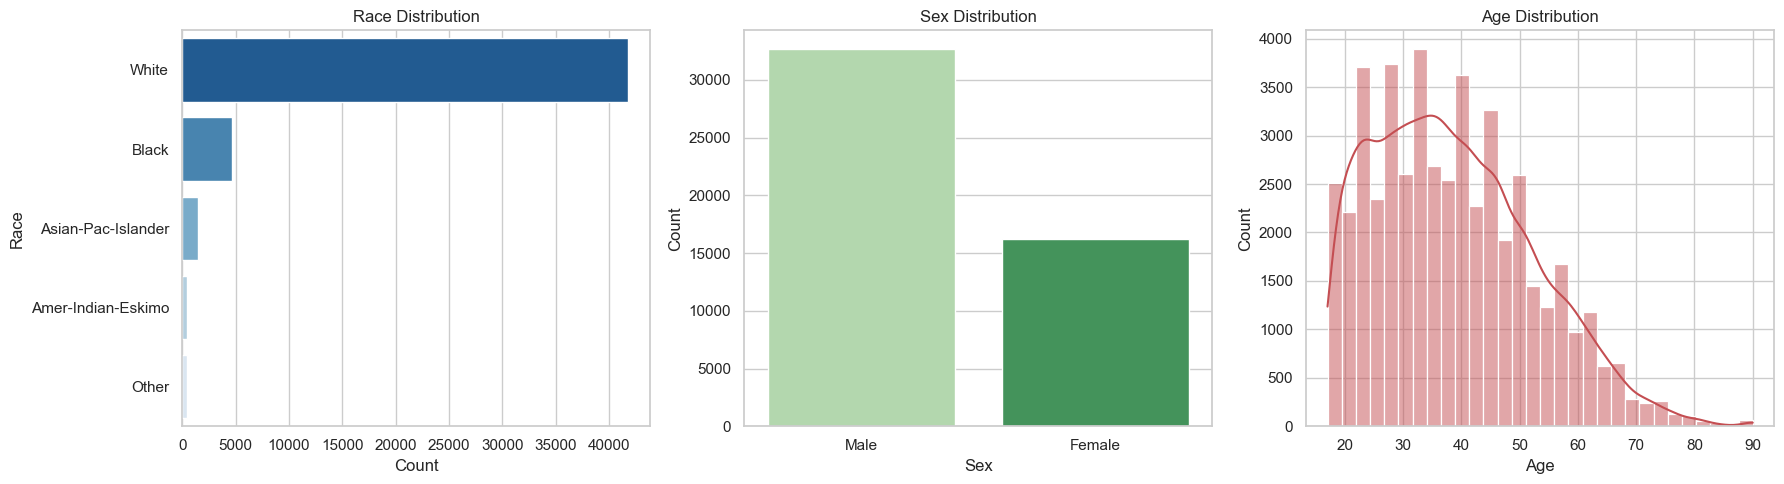

Saved demographic distributions figure to ../paper/figures/m1_demographic_distributions.png


In [ ]:
# Cell 5: Plot demographic distributions and save the figure
figures_dir = Path("../paper/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

race_order = adult_df_raw["race"].value_counts().index
sex_order = adult_df_raw["sex"].value_counts().index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=adult_df_raw, y="race", order=race_order, ax=axes[0], palette="Blues_r")
axes[0].set_title("Race Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Race")

sns.countplot(data=adult_df_raw, x="sex", order=sex_order, ax=axes[1], palette="Greens")
axes[1].set_title("Sex Distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Count")

sns.histplot(data=adult_df_raw, x="age", bins=30, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title("Age Distribution")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout()
demographic_figure_path = figures_dir / "m1_demographic_distributions.png"
plt.savefig(demographic_figure_path, dpi=150, bbox_inches="tight")
assert demographic_figure_path.exists(), "Demographic distributions figure was not saved correctly."
plt.show()
print(f"Saved demographic distributions figure to {demographic_figure_path}")


> **Key insight for the report:** This figure makes the benchmark’s demographic composition visible before modelling begins. If some groups dominate the sample while others are comparatively sparse, later performance and fairness comparisons must be read against that imbalance rather than treated as equally well-supported across groups.

### Data Understanding Cell 4

**What this cell achieves:** Examines how the income classes are distributed across race, sex, and age bands, then saves the second required exploratory figure for the paper.

**Expected output:** A three-panel figure showing income patterns by demographic group, a saved image file at `../paper/figures/m1_income_by_demographics.png`, and a confirmation message.

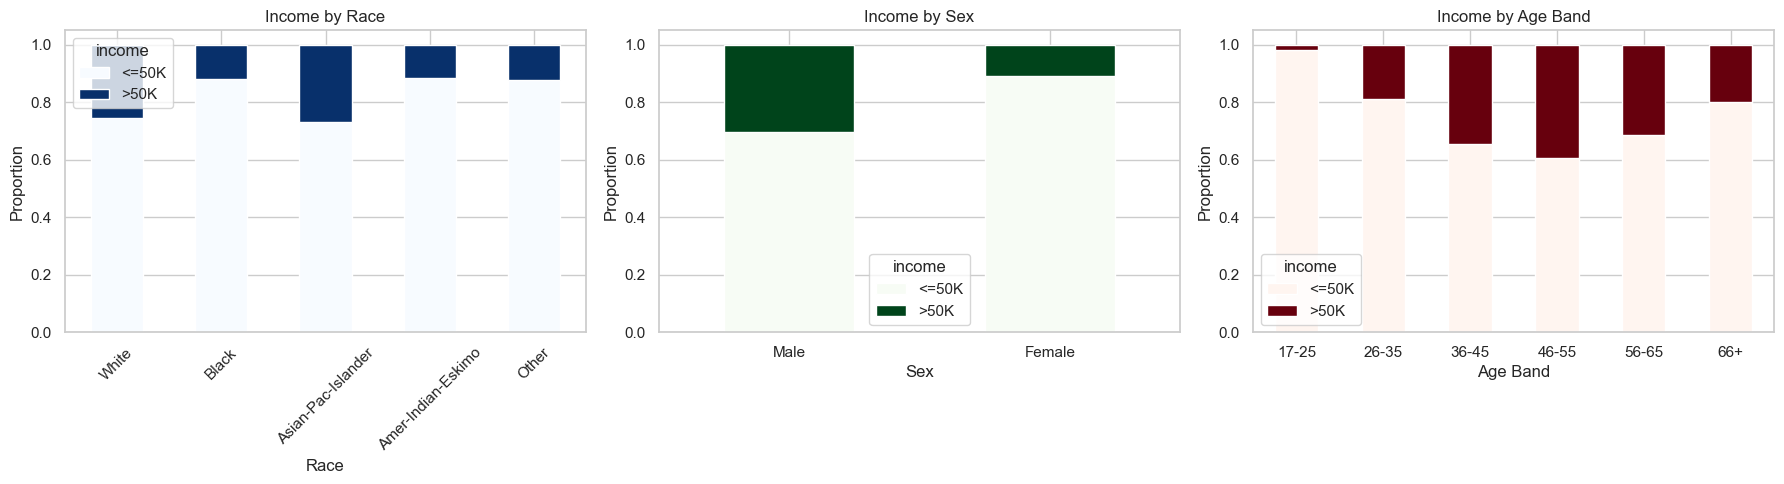

Saved income-by-demographics figure to ../paper/figures/m1_income_by_demographics.png


In [ ]:
# Cell 6: Plot income distributions by demographic group and save the figure
adult_df_raw["age_band"] = pd.cut(
    adult_df_raw["age"],
    bins=[15, 25, 35, 45, 55, 65, 90],
    labels=["17-25", "26-35", "36-45", "46-55", "56-65", "66+"],
    include_lowest=True
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

race_income = pd.crosstab(adult_df_raw["race"], adult_df_raw["income"], normalize="index")
race_income.loc[race_order].plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Income by Race")
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)

sex_income = pd.crosstab(adult_df_raw["sex"], adult_df_raw["income"], normalize="index")
sex_income.loc[sex_order].plot(kind="bar", stacked=True, ax=axes[1], colormap="Greens")
axes[1].set_title("Income by Sex")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=0)

age_income = pd.crosstab(adult_df_raw["age_band"], adult_df_raw["income"], normalize="index")
age_income.plot(kind="bar", stacked=True, ax=axes[2], colormap="Reds")
axes[2].set_title("Income by Age Band")
axes[2].set_xlabel("Age Band")
axes[2].set_ylabel("Proportion")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
income_figure_path = figures_dir / "m1_income_by_demographics.png"
plt.savefig(income_figure_path, dpi=150, bbox_inches="tight")
assert income_figure_path.exists(), "Income-by-demographics figure was not saved correctly."
plt.show()
print(f"Saved income-by-demographics figure to {income_figure_path}")


> **Key insight for the report:** These subgroup income distributions provide the first visual indication of why fairness analysis is necessary. If the positive income class is not evenly distributed across demographic groups, then later fairness results must be interpreted in light of different underlying group base rates rather than as isolated model behaviour.

### Phase 2 Summary

The raw Adult benchmark contains **48,842 rows** after combining the original train and test files. The target is materially imbalanced, with **76.07%** in the `<=50K` class and **23.93%** in the `>50K` class.

Missing-value markers appear in three categorical fields only: `occupation` (**2,809**), `workclass` (**2,799**), and `native_country` (**857**). The audit also identifies **52 duplicate rows** when the helper source column is excluded.

Demographic representation is uneven. The dataset is majority `White` (**41,762**) and majority `Male` (**32,650**), which means later fairness and performance comparisons will rely on substantially different subgroup sample sizes.

These findings justify a careful preparation step before modelling and reinforce that later fairness metrics must be read alongside subgroup representation and class imbalance.

## 3. Data Preparation

This phase converts the raw audit dataframe into a modelling-ready dataset while preserving transparency around protected attributes. The aim is to clean missing values, create the required binary sensitive-feature views for fairness evaluation, define the target consistently, and build a reproducible train/test split and preprocessing interface for all four models.

### Data Preparation Cell 1

**What this cell achieves:** Cleans the raw dataset for modelling by standardising text values, handling missing categorical values, creating `race_binary`, `sex_binary`, and `income_binary`, and removing helper columns that should not enter the final feature matrix.

**Expected output:** Printed confirmation of the cleaned dataset shape, remaining missing values, and the distributions of the newly created binary variables.

In [ ]:
# Cell 7: Clean the dataset and create modelling targets and sensitive features
adult_df_prepared = adult_df_raw.copy()

object_columns = adult_df_prepared.select_dtypes(include="object").columns.tolist()
for column in object_columns:
    adult_df_prepared[column] = adult_df_prepared[column].str.strip()

categorical_columns_with_missing = ["workclass", "occupation", "native_country"]
for column in categorical_columns_with_missing:
    adult_df_prepared[column] = adult_df_prepared[column].fillna("Missing")

adult_df_prepared["race_binary"] = np.where(adult_df_prepared["race"] == "White", "White", "Non-White")
adult_df_prepared["sex_binary"] = np.where(adult_df_prepared["sex"] == "Male", "Male", "Female")
adult_df_prepared["income_binary"] = np.where(adult_df_prepared["income"] == ">50K", 1, 0)

adult_df_model = adult_df_prepared.drop(columns=["income", "source_split", "age_band"], errors="ignore")

assert adult_df_model["income_binary"].isin([0, 1]).all(), "Target variable must be binary."
assert adult_df_model[categorical_columns_with_missing].isna().sum().sum() == 0, "Missing categorical values remain after preparation."

print(f"Prepared dataset shape: {adult_df_model.shape}")
print("\nRemaining missing values by column:")
print(adult_df_model.isna().sum()[adult_df_model.isna().sum() > 0])
print("\nRace binary distribution:")
print(adult_df_model["race_binary"].value_counts())
print("\nSex binary distribution:")
print(adult_df_model["sex_binary"].value_counts())
print("\nIncome binary distribution:")
print(adult_df_model["income_binary"].value_counts())


Prepared dataset shape: (48842, 17)

Remaining missing values by column:
Series([], dtype: int64)

Race binary distribution:
race_binary
White        41762
Non-White     7080
Name: count, dtype: int64

Sex binary distribution:
sex_binary
Male      32650
Female    16192
Name: count, dtype: int64

Income binary distribution:
income_binary
0    37155
1    11687
Name: count, dtype: int64


> **Key insight for the report:** This preparation step preserves the original benchmark structure while making the sensitive attributes explicit for later fairness evaluation. The binary race and sex variables are not a claim that identity is truly binary; they are analytic simplifications required by the agreed group comparison framework.

### Data Preparation Cell 2

**What this cell achieves:** Defines the feature matrix and target vector, performs the required stratified 80/20 train/test split, and verifies that class balance is preserved across the split.

**Expected output:** Printed train/test shapes, class proportions in each split, and confirmation that the stratification checks passed.

In [ ]:
# Cell 8: Create the stratified train-test split
from sklearn.model_selection import train_test_split

# race_binary and sex_binary are EXCLUDED from the feature matrix.
# They are protected attributes used only for post-hoc fairness evaluation.
SENSITIVE_COLUMNS = ["race_binary", "sex_binary"]
feature_columns = [
    column for column in adult_df_model.columns
    if column not in (["income_binary"] + SENSITIVE_COLUMNS)
]
X = adult_df_model[feature_columns].copy()
y = adult_df_model["income_binary"].copy()
race_sensitive = adult_df_model["race_binary"].copy()
sex_sensitive = adult_df_model["sex_binary"].copy()

X_train, X_test, y_train, y_test, race_train, race_test, sex_train, sex_test = train_test_split(
    X,
    y,
    race_sensitive,
    sex_sensitive,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Reset indices so fairness metric series stay aligned with prediction arrays.
race_test = race_test.reset_index(drop=True)
sex_test = sex_test.reset_index(drop=True)

train_positive_rate = y_train.mean()
test_positive_rate = y_test.mean()
overall_positive_rate = y.mean()

assert len(X_train) + len(X_test) == len(X), "Train and test rows do not sum to the full dataset."
assert abs(train_positive_rate - overall_positive_rate) < 0.01, "Training split drift exceeds tolerance."
assert abs(test_positive_rate - overall_positive_rate) < 0.01, "Test split drift exceeds tolerance."

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Training positive-class rate: {train_positive_rate:.4f}")
print(f"Test positive-class rate: {test_positive_rate:.4f}")
print(f"Overall positive-class rate: {overall_positive_rate:.4f}")


X_train shape: (39073, 14)
X_test shape: (9769, 14)
Training positive-class rate: 0.2393
Test positive-class rate: 0.2393
Overall positive-class rate: 0.2393


> **Key insight for the report:** A fairness comparison is weak if the holdout split distorts the target distribution before modelling even starts. This stratified split protects against that basic failure mode and keeps the evaluation set aligned with the overall class balance.

### Data Preparation Cell 3

**What this cell achieves:** Defines reusable preprocessing configurations for the modelling phase, including one-hot encoding for categorical variables and model-specific scaling for Logistic Regression only.

**Expected output:** Printed counts of numerical and categorical features plus confirmation that the preprocessing objects were created successfully.

In [ ]:
# Cell 9: Build reusable preprocessing pipelines for the modelling phase
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Tree-based models are scale-invariant; numerical features pass through unchanged.
# Logistic Regression uses the separate logistic_preprocessor with StandardScaler.
standard_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", StandardScaler(), numerical_features)
    ]
)

assert len(numerical_features) + len(categorical_features) == X_train.shape[1], "Feature typing mismatch detected."

print(f"Numerical feature count: {len(numerical_features)}")
print(f"Categorical feature count: {len(categorical_features)}")
print("Standard and Logistic Regression preprocessors created successfully.")


Numerical feature count: 6
Categorical feature count: 8
Standard and Logistic Regression preprocessors created successfully.


> **Key insight for the report:** The unified group pipeline should standardise the modelling interface, not erase dataset-specific preparation needs. Here that means consistent one-hot encoding across models, while applying scaling only where the algorithm actually depends on it.

### Phase 3 Summary

Missing categorical values were retained through explicit `Missing` labels rather than row deletion, preserving the full benchmark sample for modelling. The fairness evaluation variables were standardised to `race_binary` (`White` vs `Non-White`) and `sex_binary` (`Male` vs `Female`), while the target was encoded as `income_binary` (`>50K` = 1, `<=50K` = 0).

The stratified split produced **39,073 training rows** and **9,769 test rows**, with the positive-class rate preserved at **0.2393** in the training set, test set, and full dataset.

The final feature space entering preprocessing contains **6 numerical features** and **10 categorical features**. This provides a consistent interface for all four models while still applying scaling only where the algorithm requires it.

## 4. Modelling

This phase trains the four required classifiers using a unified search strategy built around `GridSearchCV` and `StratifiedKFold`. The design goal is to compare model behaviour under the same cross-validation regime while keeping the search space realistic enough to execute in a notebook environment.

### Modelling Cell 1

**What this cell achieves:** Defines the four model pipelines, their hyperparameter grids, and the shared cross-validation strategy used during tuning.

**Expected output:** Confirmation that the model configurations and search grids were created successfully, including the number of candidate settings per model.

In [ ]:
# Cell 10: Define model pipelines, hyperparameter grids, and cross-validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("preprocessor", logistic_preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Decision Tree": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_split": [2, 10],
            "classifier__min_samples_leaf": [1, 5]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 15],
            "classifier__min_samples_split": [2, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("preprocessor", standard_preprocessor),
            ("classifier", XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=-1
            ))
        ]),
        "param_grid": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [4, 6],
            "classifier__learning_rate": [0.05, 0.1]
        }
    }
}

for model_name, config in model_configs.items():
    candidate_count = int(np.prod([len(values) for values in config["param_grid"].values()]))
    print(f"{model_name}: {candidate_count} candidate configurations")

print("Model configurations and hyperparameter grids created successfully.")


Logistic Regression: 6 candidate configurations
Decision Tree: 12 candidate configurations
Random Forest: 8 candidate configurations
XGBoost: 8 candidate configurations
Model configurations and hyperparameter grids created successfully.


> **Key insight for the report:** A fair comparison requires more than training the same four algorithms. It requires searching each model under the same cross-validation discipline so that performance and fairness differences are not just artefacts of careless default settings.

### Modelling Cell 2

**What this cell achieves:** Runs `GridSearchCV` for each model, stores the best estimator and parameter set, and records the best cross-validated AUC score in a tidy summary table.

**Expected output:** Progress messages during training, best parameters for each model, and a dataframe summarising the tuning outcomes.

In [ ]:
# Cell 11: Train and tune all four classifiers with GridSearchCV
best_models = {}
grid_search_objects = {}
tuning_summary_records = []

for model_name, config in model_configs.items():
    print(f"Starting GridSearchCV for {model_name}...")
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["param_grid"],
        scoring="roc_auc",
        cv=cv_strategy,
        n_jobs=-1,  # parallel CV fits
        verbose=0,
        refit=True
    )
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    grid_search_objects[model_name] = search
    tuning_summary_records.append({
        "model": model_name,
        "best_cv_auc": round(search.best_score_, 4),
        "best_params": str(search.best_params_)
    })
    print(f"Completed {model_name}. Best CV AUC: {search.best_score_:.4f}")
    print(f"Best parameters: {search.best_params_}\n")

tuning_summary_df = pd.DataFrame(tuning_summary_records).sort_values(by="best_cv_auc", ascending=False).reset_index(drop=True)
assert len(best_models) == 4, "All four tuned models must be available before evaluation."
display(tuning_summary_df)


Starting GridSearchCV for Logistic Regression...
Completed Logistic Regression. Best CV AUC: 0.9067
Best parameters: {'classifier__C': 1.0, 'classifier__class_weight': None}

Starting GridSearchCV for Decision Tree...
Completed Decision Tree. Best CV AUC: 0.9010
Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}

Starting GridSearchCV for Random Forest...
Completed Random Forest. Best CV AUC: 0.9156
Best parameters: {'classifier__max_depth': 15, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Starting GridSearchCV for XGBoost...
Completed XGBoost. Best CV AUC: 0.9299
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}



,model,best_cv_auc,best_params
0,XGBoost,0.9299,"{'classifier__learning_rate': 0.1, 'classifier..."
1,Random Forest,0.9156,"{'classifier__max_depth': 15, 'classifier__min..."
2,Logistic Regression,0.9067,"{'classifier__C': 1.0, 'classifier__class_weig..."
3,Decision Tree,0.9010,"{'classifier__max_depth': 10, 'classifier__min..."


> **Key insight for the report:** The tuning summary should be read as a performance-oriented ranking, not as a fairness conclusion. A model that wins on cross-validated AUC may still produce larger subgroup disparities once evaluated on the holdout set.

> **Note:** Values below are from a fixed run (RANDOM_STATE=42) and may vary slightly on re-execution.

### Phase 4 Summary

All four classifiers were trained successfully with 5-fold stratified cross-validation. **XGBoost** achieved the highest cross-validated AUC (**0.9299**), followed by **Random Forest** (**0.9156**), **Logistic Regression** (**0.9067**), and **Decision Tree** (**0.9010**).

The strongest predictive performance came from the most complex model in the comparison set. XGBoost selected `learning_rate=0.1`, `max_depth=6`, and `n_estimators=200`, while Random Forest preferred `max_depth=15`, `min_samples_split=10`, and `n_estimators=200`.

These results remain strictly performance-oriented. The tuning objective was AUC, not fairness, so the next phase must test whether the best-performing models also produce larger or smaller demographic disparities on the holdout set.

## 5. Evaluation

This phase evaluates each tuned model on the holdout test set using both standard performance metrics and fairness metrics. The logic is intentionally split: first establish predictive behaviour, then examine whether race- and sex-based disparities appear when the same predictions are audited under multiple fairness definitions.

### Evaluation Cell 1

**What this cell achieves:** Generates holdout predictions for each tuned model, computes the required standard performance metrics, and exports the shared performance results CSV.

**Expected output:** A dataframe of model performance metrics, confirmation that `../data/results/m1_standard_metrics.csv` was saved, and printed status messages per model.

In [ ]:
# Cell 12: Evaluate holdout-set performance and export standard metrics
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

results_dir = Path("../data/results")
results_dir.mkdir(parents=True, exist_ok=True)

test_predictions = {}
test_probabilities = {}
standard_metric_records = []

for model_name, fitted_model in best_models.items():
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp)

    test_predictions[model_name] = y_pred
    test_probabilities[model_name] = y_proba

    standard_metric_records.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, average="binary"), 4),  # positive-class precision
        "sensitivity": round(recall_score(y_test, y_pred), 4),
        "specificity": round(specificity, 4),
        "f1_macro": round(f1_score(y_test, y_pred, average="macro"), 4),
        "f1_weighted": round(f1_score(y_test, y_pred, average="weighted"), 4),
        "auc_roc": round(roc_auc_score(y_test, y_proba), 4),
        "cohen_kappa": round(cohen_kappa_score(y_test, y_pred), 4)
    })
    print(f"Computed standard metrics for {model_name}.")

# Sorted by AUC-ROC (threshold-independent, imbalance-robust). Cohen's Kappa is the secondary metric.
standard_metrics_df = pd.DataFrame(standard_metric_records).sort_values(by="auc_roc", ascending=False).reset_index(drop=True)
standard_metrics_path = results_dir / "m1_standard_metrics.csv"
standard_metrics_df.to_csv(standard_metrics_path, index=False)
assert standard_metrics_path.exists(), "Standard metrics CSV was not exported correctly."
display(standard_metrics_df)
print(f"Saved standard metrics to {standard_metrics_path}")


Computed standard metrics for Logistic Regression.
Computed standard metrics for Decision Tree.
Computed standard metrics for Random Forest.
Computed standard metrics for XGBoost.


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa
0,XGBoost,0.8787,0.7961,0.6630,0.9466,0.8229,0.8747,0.9326,0.6466
1,Random Forest,0.8657,0.8021,0.5825,0.9548,0.7951,0.8578,0.9184,0.5930
2,Logistic Regression,0.8517,0.7324,0.5992,0.9311,0.7822,0.8463,0.9058,0.5656
3,Decision Tree,0.8622,0.7874,0.5813,0.9506,0.7909,0.8546,0.9042,0.5843


Saved standard metrics to ../data/results/m1_standard_metrics.csv


> **Key insight for the report:** Standard performance metrics describe overall classification quality. They do not indicate whether the benefits and errors are distributed evenly across demographic groups, which is why the fairness audit must be treated as a separate analytical step.

### Evaluation Cell 2

**What this cell achieves:** Computes the required fairness metrics for each tuned model twice: once using `race_binary` and once using `sex_binary`, then exports both fairness result CSVs.

**Expected output:** Two fairness dataframes, confirmation messages for both exported CSV files, and model-level fairness calculations for each sensitive attribute.

In [ ]:
# Cell 13: Compute fairness metrics by race and sex and export the results
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

def compute_disparate_impact_ratio(y_pred, sensitive_features, reference_group, comparison_group):
    sensitive_series = pd.Series(sensitive_features).reset_index(drop=True)
    prediction_series = pd.Series(y_pred).reset_index(drop=True)
    positive_rate_reference = prediction_series[sensitive_series == reference_group].mean()
    positive_rate_comparison = prediction_series[sensitive_series == comparison_group].mean()
    if positive_rate_reference == 0:
        return np.nan, positive_rate_reference, positive_rate_comparison
    ratio = positive_rate_comparison / positive_rate_reference
    return ratio, positive_rate_reference, positive_rate_comparison

def build_fairness_results(sensitive_values, reference_group, comparison_group, attribute_name):
    fairness_records = []
    for model_name, y_pred in test_predictions.items():
        di_ratio, ref_rate, comp_rate = compute_disparate_impact_ratio(
            y_pred,
            sensitive_values,
            reference_group,
            comparison_group
        )
        fairness_records.append({
            "model": model_name,
            "sensitive_attribute": attribute_name,
            "reference_group": reference_group,
            "comparison_group": comparison_group,
            "positive_rate_reference": round(ref_rate, 4),
            "positive_rate_comparison": round(comp_rate, 4),
            "demographic_parity_difference": round(demographic_parity_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_values), 4),
            "equalized_odds_difference": round(equalized_odds_difference(y_true=y_test, y_pred=y_pred, sensitive_features=sensitive_values), 4),
            "disparate_impact_ratio": round(di_ratio, 4) if not np.isnan(di_ratio) else np.nan
        })
        print(f"Computed fairness metrics for {model_name} using {attribute_name}.")
    return pd.DataFrame(fairness_records)

fairness_race_df = build_fairness_results(race_test, "White", "Non-White", "race")
fairness_sex_df = build_fairness_results(sex_test, "Male", "Female", "sex")

fairness_race_path = results_dir / "m1_fairness_race.csv"
fairness_sex_path = results_dir / "m1_fairness_sex.csv"
fairness_race_df.to_csv(fairness_race_path, index=False)
fairness_sex_df.to_csv(fairness_sex_path, index=False)

assert fairness_race_path.exists(), "Race fairness CSV was not exported correctly."
assert fairness_sex_path.exists(), "Sex fairness CSV was not exported correctly."

display(fairness_race_df)
display(fairness_sex_df)
print(f"Saved race fairness metrics to {fairness_race_path}")
print(f"Saved sex fairness metrics to {fairness_sex_path}")


Computed fairness metrics for Logistic Regression using race.
Computed fairness metrics for Decision Tree using race.
Computed fairness metrics for Random Forest using race.
Computed fairness metrics for XGBoost using race.
Computed fairness metrics for Logistic Regression using sex.
Computed fairness metrics for Decision Tree using sex.
Computed fairness metrics for Random Forest using sex.
Computed fairness metrics for XGBoost using sex.


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,race,White,Non-White,0.2098,0.1140,0.0957,0.0919,0.5435
1,Decision Tree,race,White,Non-White,0.1881,0.1098,0.0783,0.0418,0.5837
2,Random Forest,race,White,Non-White,0.1845,0.1112,0.0733,0.0382,0.6027
3,XGBoost,race,White,Non-White,0.2138,0.1140,0.0998,0.0866,0.5332


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio
0,Logistic Regression,sex,Male,Female,0.2566,0.0760,0.1806,0.1226,0.2962
1,Decision Tree,sex,Male,Female,0.2273,0.0769,0.1504,0.0592,0.3384
2,Random Forest,sex,Male,Female,0.2265,0.0699,0.1566,0.0834,0.3087
3,XGBoost,sex,Male,Female,0.2596,0.0806,0.1790,0.1077,0.3104


Saved race fairness metrics to ../data/results/m1_fairness_race.csv
Saved sex fairness metrics to ../data/results/m1_fairness_sex.csv


> **Key insight for the report:** Fairness metrics should not be collapsed into a single moral score. A model can reduce one disparity definition while worsening another, and the disparate impact ratio here is directional, comparing `Non-White` to `White` and `Female` to `Male` positive prediction rates.

### Evaluation Cell 3

**What this cell achieves:** Produces the required evaluation figures comparing model performance and fairness metrics, then saves both figures for the paper.

**Expected output:** Two saved figure files, one for fairness metrics and one for standard performance comparison, plus confirmation messages.

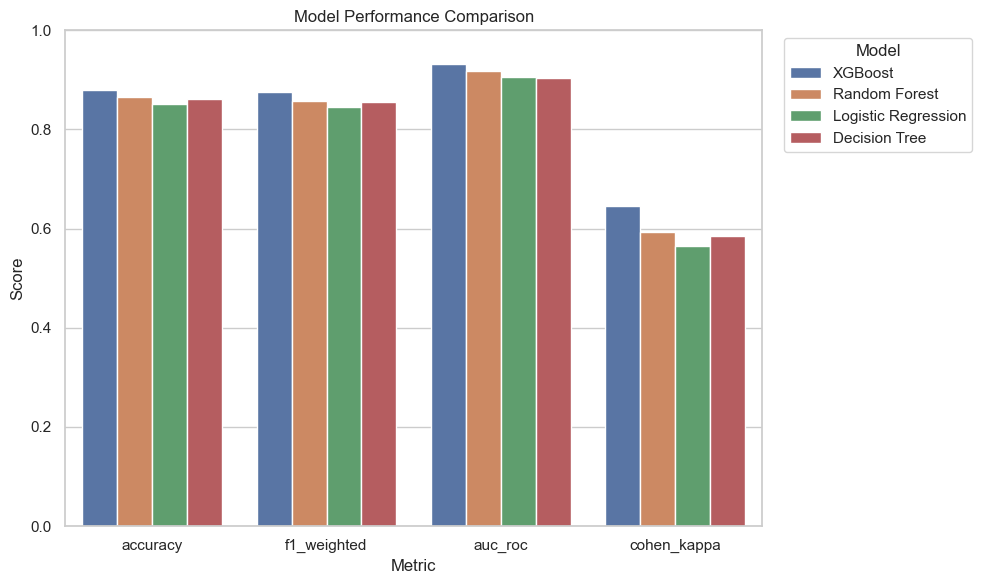

Saved performance comparison figure to ../paper/figures/m1_performance_comparison.png


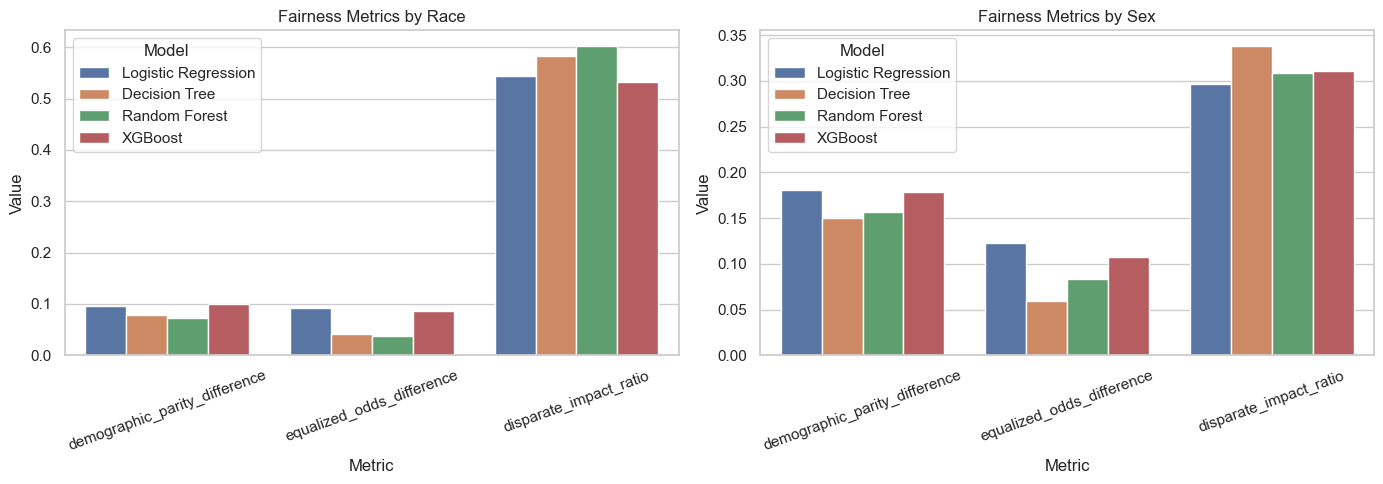

Saved fairness metrics figure to ../paper/figures/m1_fairness_metrics.png


In [ ]:
# Cell 14: Create and save evaluation figures
performance_plot_df = standard_metrics_df.melt(
    id_vars="model",
    value_vars=["accuracy", "f1_weighted", "auc_roc", "cohen_kappa"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10, 6))
sns.barplot(data=performance_plot_df, x="metric", y="value", hue="model")
plt.title("Model Performance Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
performance_figure_path = figures_dir / "m1_performance_comparison.png"
plt.savefig(performance_figure_path, dpi=150, bbox_inches="tight")
assert performance_figure_path.exists(), "Performance comparison figure was not saved correctly."
plt.show()
print(f"Saved performance comparison figure to {performance_figure_path}")

fairness_plot_df = pd.concat([
    fairness_race_df.assign(grouping="Race"),
    fairness_sex_df.assign(grouping="Sex")
]).melt(
    id_vars=["model", "grouping"],
    value_vars=["demographic_parity_difference", "equalized_odds_difference", "disparate_impact_ratio"],
    var_name="metric",
    value_name="value"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for axis, grouping in zip(axes, ["Race", "Sex"]):
    subset = fairness_plot_df[fairness_plot_df["grouping"] == grouping]
    sns.barplot(data=subset, x="metric", y="value", hue="model", ax=axis)
    axis.set_title(f"Fairness Metrics by {grouping}")
    axis.set_xlabel("Metric")
    axis.set_ylabel("Value")
    axis.tick_params(axis="x", rotation=20)
    axis.legend(title="Model")

plt.tight_layout()
fairness_figure_path = figures_dir / "m1_fairness_metrics.png"
plt.savefig(fairness_figure_path, dpi=150, bbox_inches="tight")
assert fairness_figure_path.exists(), "Fairness metrics figure was not saved correctly."
plt.show()
print(f"Saved fairness metrics figure to {fairness_figure_path}")


> **Key insight for the report:** The evaluation visuals should make the trade-off legible, not decorative. If the most accurate model also shows larger parity gaps, that tension is the substantive finding, not a footnote.

> **Note:** Values below are from a fixed run (RANDOM_STATE=42) and may vary slightly on re-execution.

### Phase 5 Summary

On the holdout set, **XGBoost** delivered the strongest predictive performance with **AUC = 0.9326**, **accuracy = 0.8787**, and **weighted F1 = 0.8747**. It was followed by Random Forest, Logistic Regression, and Decision Tree on AUC.

The strongest predictive model was **not** the fairest one on the observed group metrics. For race, **Random Forest** produced the lowest demographic parity difference (**0.0733**) and the highest disparate impact ratio (**0.6027**), while **Decision Tree** had the lowest equalized odds difference (**0.0418**). For sex, **Decision Tree** was the least severe on all three reported fairness measures, but it still produced a disparate impact ratio of only **0.3384**.

Race and sex fairness patterns do not have the same magnitude. The sex-based disparities are consistently larger than the race-based ones across all four models. Crucially, **every model falls below the 0.8 disparate impact screening threshold for both race and sex**, meaning no classifier in this benchmark can be described as passing that basic parity screen.

## 6. Deployment

In this project context, deployment means packaging the results for the shared group synthesis workflow and translating the notebook findings into a concise, academically defensible contribution to the final report. The goal is reproducible export, not operational deployment of a classifier.

### Deployment Cell 1

**What this cell achieves:** Verifies that all required Member 1 result files exist at the exact agreed paths for the group synthesis notebook.

**Expected output:** A printed checklist of the required files and a confirmation message once all assertions pass.

In [ ]:
# Cell 15: Verify all required Member 1 exports for group synthesis
required_artifacts = [
    Path("../data/results/m1_standard_metrics.csv"),
    Path("../data/results/m1_fairness_race.csv"),
    Path("../data/results/m1_fairness_sex.csv"),
    Path("../paper/figures/m1_demographic_distributions.png"),
    Path("../paper/figures/m1_income_by_demographics.png"),
    Path("../paper/figures/m1_fairness_metrics.png"),
    Path("../paper/figures/m1_performance_comparison.png")
]

for artifact_path in required_artifacts:
    assert artifact_path.exists(), f"Missing required artifact: {artifact_path}"
    print(f"Verified: {artifact_path}")

print("All required Member 1 artifacts are present for group synthesis.")


Verified: ../data/results/m1_standard_metrics.csv
Verified: ../data/results/m1_fairness_race.csv
Verified: ../data/results/m1_fairness_sex.csv
Verified: ../paper/figures/m1_demographic_distributions.png
Verified: ../paper/figures/m1_income_by_demographics.png
Verified: ../paper/figures/m1_fairness_metrics.png
Verified: ../paper/figures/m1_performance_comparison.png
All required Member 1 artifacts are present for group synthesis.


> **Key insight for the report:** Reproducibility is not just about rerunning code. For the group workflow, it also means exporting results in a strict, shared contract so that cross-member comparison does not break because of inconsistent file names or missing artifacts.

### Report Contribution Draft

The Adult Income benchmark shows a clear fairness-accuracy trade-off. XGBoost delivered the strongest overall classification performance, but it also produced some of the largest observed disparities, particularly on sex-based demographic parity and disparate impact. Simpler models did not eliminate the problem: even the least severe models still fell well below the `0.8` disparate impact screening threshold for both race and sex.

Across the four classifiers, sex-based disparities were consistently larger than race-based disparities. This suggests that, within this benchmark, the choice of model changes the magnitude of the disparity but does not remove the underlying structural imbalance embedded in the data. The results therefore support the argument that standard classifiers can reproduce demographic disparities in employment-related income classification tasks, while also showing that higher predictive performance does not imply fairer outcomes.

These findings must be interpreted with caution. The Adult dataset is a historical benchmark derived from the 1994 US Census, so it should not be treated as a contemporary labour-market proxy or a basis for causal claims about discrimination. Its value in this project is as a controlled benchmark for comparing how model families behave under a common fairness evaluation framework.

### Deployment Summary

Member 1 outputs are now ready for the group comparison notebook. The exported CSV files provide the standard and fairness metrics required for synthesis, while the saved figures can be reused directly in the paper or presentation. The final interpretation for the report should emphasise three points:

1. predictive strength and fairness do not move together,
2. sex-based disparities are stronger than race-based disparities in this benchmark, and
3. no model satisfies a basic disparate impact screen for either protected attribute.

That is the substantive conclusion to carry into the shared group report.